In [ ]:

# Case Study 1: Hospital Readmission Prediction

### Machine Learning Engineering CA1

# **Objective:**
 # Predict whether a patient will be readmitted to the hospital within 30 days
 # using Logistic Regression with L2 regularization.

# **Evaluation Metric:** ROC-AUC

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

In [26]:
df = pd.read_csv("diabetic_data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (44110, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [27]:

df["target"] = (df["readmitted"] == "<30").astype(int)

print(df["target"].value_counts())

target
0    39060
1     5050
Name: count, dtype: int64


In [28]:
features = [
    "diag_1",
    "diag_2",
    "diag_3",
    "time_in_hospital",
    "num_lab_procedures",
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

data = df[features + ["target"]].replace("?", pd.NA).dropna()
print("Data after preprocessing:", data.shape)

Data after preprocessing: (43029, 9)


In [29]:

for col in ["diag_1", "diag_2", "diag_3"]:
    data[col] = LabelEncoder().fit_transform(data[col].astype(str))

X = data[features]
y = data["target"]

print("Features:", X.shape)

Features: (43029, 8)


In [30]:

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)

Training data: (34423, 8)
Validation data: (8606, 8)


In [31]:
# Logistic Regression with L2 regularization
model = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    max_iter=1000
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [32]:
# Logistic Regression with L2 regularization
model = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    max_iter=1000
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [33]:
# Validation performance
y_prob = model.predict_proba(X_val)[:, 1]

auc = roc_auc_score(y_val, y_prob)

print("Validation ROC-AUC:", auc)

Validation ROC-AUC: 0.6306564221642439


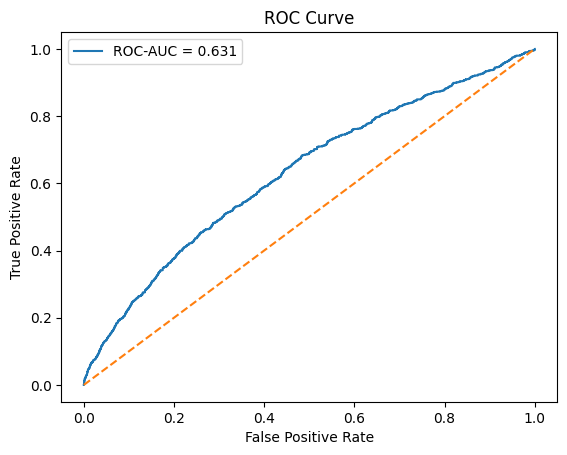

In [34]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob)

plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:

# Classification using 0.5 threshold
y_pred = (y_prob >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

print("True Positive :", tp)
print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)

True Positive : 248
True Negative : 2680
False Positive: 1135
False Negative: 263
